# HW3: Model Predictive Control
# Part 2: Crocoddyl
Ting-Wei Hsu (twhsu3)

It is organized to solve the assignment in two parts:

1. **Single optimized trajectories** for four stages:
   - no limits / no collisions,
   - joint limits + torque bounds,
   - self-collision barriers,
   - obstacle barrier.
2. **Warm-started MPC** for two laps around the circle, with three obstacle placements.

Important implementation choices:

- Joint **torque limits** are enforced as Crocoddyl box bounds via `SolverBoxFDDP`.
- Joint **position / velocity limits** are implemented as quadratic barrier costs with `ActivationBounds`.
- Self-collision and obstacle avoidance are implemented with `ResidualModelPairCollision` and `ActivationModel2NormBarrier`.
- The closed-loop simulation step uses **ABA + RK4 + `pin.integrate`** rather than reusing the discretization inside the optimal-control model.

In [209]:
# Rigid body dynamics (pinocchio)
import pinocchio as pin

# Collision checking
import coal

# Optimal control
import crocoddyl

# Visualization (meshcat)
from pinocchio.visualize import MeshcatVisualizer
import meshcat_shapes

# Robot models (robot_descriptions)
from robot_descriptions.loaders.pinocchio import load_robot_description

# Math
import numpy as np

# Timing
import time

# Plots
import matplotlib.pyplot as plt

# Suppress the display of very small numbers
np.set_printoptions(suppress=True)

## Universal Robots UR10
The Universal Robots UR10 is a 6-joint collaborative robot arm.

Load a robot model.

In [210]:
# Load model
robot = load_robot_description(
    'ur10_description',           # name of robot model
    root_joint=None,                # fixed base
)

Enable checking for self-collision.

In [211]:
# Add all pairs
robot.collision_model.addAllCollisionPairs()

# List useless collision pairs
useless_pairs = [7, 13, 18, 22, 25]

# Remove useless collision pairs
for i in sorted(useless_pairs, reverse=True):
    robot.collision_model.removeCollisionPair(robot.collision_model.collisionPairs[i])

Define function to convert each primitive geometry to a convex mesh by sampling its surface.

In [212]:
def primitive_to_convex(shape, n=32):
    """
    Convert a coal primitive shape to a ConvexBase by sampling
    its surface, building a BVHModel from the points, and computing
    the convex hull.
    """
    if isinstance(shape, coal.Box):
        # half-extents
        x, y, z = shape.halfSide
        verts = np.array([
            [ x,  y,  z], [ x,  y, -z], [ x, -y,  z], [ x, -y, -z],
            [-x,  y,  z], [-x,  y, -z], [-x, -y,  z], [-x, -y, -z],
        ])

    elif isinstance(shape, coal.Cylinder):
        r = shape.radius
        h = shape.halfLength
        theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
        circle = np.column_stack([r * np.cos(theta), r * np.sin(theta)])
        top = np.column_stack([circle, np.full(n, h)])
        bot = np.column_stack([circle, np.full(n, -h)])
        verts = np.vstack([top, bot])

    elif isinstance(shape, coal.Cone):
        r = shape.radius
        h = shape.halfLength
        theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
        base = np.column_stack([r * np.cos(theta), r * np.sin(theta),
                                np.full(n, -h)])
        apex = np.array([[0.0, 0.0, h]])
        verts = np.vstack([base, apex])

    elif isinstance(shape, coal.Sphere):
        verts = _sphere_points(shape.radius, n)

    elif isinstance(shape, coal.Ellipsoid):
        rx, ry, rz = shape.radii
        unit = _sphere_points(1.0, n)
        verts = unit * np.array([rx, ry, rz])

    elif isinstance(shape, coal.Capsule):
        r = shape.radius
        h = shape.halfLength
        # hemisphere + cylinder ring
        unit = _sphere_points(1.0, n)
        top_hemi = unit[unit[:, 2] >= 0] * r + [0, 0, h]
        bot_hemi = unit[unit[:, 2] <= 0] * r + [0, 0, -h]
        theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
        ring = np.column_stack([r * np.cos(theta), r * np.sin(theta),
                                np.zeros(n)])
        verts = np.vstack([top_hemi, bot_hemi,
                           ring + [0, 0, h], ring + [0, 0, -h]])

    else:
        raise TypeError(f"Unsupported shape type: {type(shape)}")

    return _points_to_convex(verts)


def _sphere_points(radius, n):
    """Fibonacci sphere sampling."""
    indices = np.arange(n * n // 2)  # enough points
    # Use a simpler grid approach
    u = np.linspace(0, 2 * np.pi, n, endpoint=False)
    v = np.linspace(0, np.pi, n // 2 + 1)
    theta, phi = np.meshgrid(u, v)
    theta, phi = theta.ravel(), phi.ravel()
    x = radius * np.sin(phi) * np.cos(theta)
    y = radius * np.sin(phi) * np.sin(theta)
    z = radius * np.cos(phi)
    return np.column_stack([x, y, z])


def _points_to_convex(points):
    """Build a BVHModel from a point cloud and compute its convex hull."""
    bvh = coal.BVHModelOBBRSS()
    bvh.beginModel(0, len(points))
    bvh.addVertices(points)
    bvh.endModel()
    bvh.buildConvexHull(True, "Qt")
    return bvh.convex

Apply function to convert all collision geometries to convex meshes.

In [213]:
# Choose sampling density
n = 32

# Apply function
for geom_obj in robot.collision_model.geometryObjects:
    geom = geom_obj.geometry
    if isinstance(geom, coal.ConvexBase):
        print(f'No need to convert "{geom_obj.name}" (already a convex mesh)')
        continue
    elif isinstance(geom, coal.BVHModelBase):
        print(f'Convert "{geom_obj.name}" (buildConvexHull)')
        geom.buildConvexHull(True, "Qt")
        geom_obj.geometry = geom.convex
    elif isinstance(geom, coal.ShapeBase):
        print(f'Convert "{geom_obj.name}" (primitive_to_convex)')
        geom_obj.geometry = primitive_to_convex(geom, n=n)
    else:
        print(f'Not sure what to do with "{geom_obj.name}"')

Convert "base_link_0" (buildConvexHull)
Convert "shoulder_link_0" (buildConvexHull)
Convert "upper_arm_link_0" (buildConvexHull)
Convert "forearm_link_0" (buildConvexHull)
Convert "wrist_1_link_0" (buildConvexHull)
Convert "wrist_2_link_0" (buildConvexHull)
Convert "wrist_3_link_0" (buildConvexHull)
Convert "ee_link_0" (primitive_to_convex)


Make all collision objects semi-transparent.

In [214]:
for go in robot.collision_model.geometryObjects:
    go.meshColor[-1] = 0.3

for go in robot.visual_model.geometryObjects:
    go.meshColor[-1] = 0.7

Update robot data.

In [215]:
robot.data = robot.model.createData()
robot.collision_data = robot.collision_model.createData()
robot.visual_data = robot.visual_model.createData()

Display robot (and obstacles) in browser.

In [216]:
# Create a visualizer
vis = MeshcatVisualizer(robot.model, robot.collision_model, robot.visual_model)
robot.setVisualizer(vis, init=False)
vis.initViewer(open=True)
vis.loadViewerModel()

# Pause to allow meshcat initialization to finish
time.sleep(0.1)

# Choose what to display
vis.displayFrames(False)
vis.displayVisuals(True)
vis.displayCollisions(True)

# Add our own frames to the visualizer because the default frames are hard to see
frames_to_show = [
    'base_link',
    'shoulder_link',
    'upper_arm_link',
    'forearm_link',
    'wrist_1_link',
    'wrist_2_link',
    'wrist_3_link',
    'ee_link',
]
for frame in frames_to_show:
    meshcat_shapes.frame(
        vis.viewer['frames/' + frame],
        opacity=0.5,
        axis_length=0.1,
        axis_thickness=0.0025,
        origin_radius=0.005,
    )

# Pause to allow meshcat initialization to finish
time.sleep(0.1)

vis.displayFrames(False)

# Change the camera view
vis.setCameraPosition(np.array([0., 2., 0.75]))
vis.setCameraTarget(np.array([0., 0., 0.75]))

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7014/static/


/usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: iceweasel: not found
/usr/bin/xdg-open: 882: seamonkey: not found
/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: epiphany: not found
/usr/bin/xdg-open: 882: konqueror: not found
/usr/bin/xdg-open: 882: chromium: not found
/usr/bin/xdg-open: 882: chromium-browser: not found
/usr/bin/xdg-open: 882: google-chrome: not found
/usr/bin/xdg-open: 882: www-browser: not found


Put the robot at its "neutral" configuration.

In [217]:
# Get and show the neutral configuration (most likely all zeros)
q = pin.neutral(robot.model)
print(f'{q = }')

# Do forward kinematics
# - Compute the placement of all joint frames (modifies robot.data but not robot.model or q)
pin.forwardKinematics(robot.model, robot.data, q)
# - Compute the placement of all link frames (modifies robot.data but not robot.model)
pin.updateFramePlacements(robot.model, robot.data)
# - Compute the placement of all collision geometry objects
pin.updateGeometryPlacements(
    robot.model,
    robot.data,
    robot.collision_model,
    robot.collision_data,
)

# Show the configuration in the visualizer
vis.display(q)
#for frame in frames_to_show:
#    frame_id = robot.model.getFrameId(frame)
#    vis.viewer['frames/' + frame].set_transform(robot.data.oMf[frame_id].homogeneous)

q = array([0., 0., 0., 0., 0., 0.])


## 1. Define and solve a single optimal control problem

Check that all limits are finite.

In [218]:
with np.printoptions(precision=2):
    print('ALL LIMITS MUST BE FINITE')
    print(f' lowerPositionLimit: {robot.model.lowerPositionLimit}')
    print(f' upperPositionLimit: {robot.model.upperPositionLimit}')
    print(f'      velocityLimit: {robot.model.velocityLimit}')
    print(f'        effortLimit: {robot.model.effortLimit}')

ALL LIMITS MUST BE FINITE
 lowerPositionLimit: [-6.28 -6.28 -3.14 -6.28 -6.28 -6.28]
 upperPositionLimit: [6.28 6.28 3.14 6.28 6.28 6.28]
      velocityLimit: [2.16 2.16 3.15 3.2  3.2  3.2 ]
        effortLimit: [330. 330. 150.  54.  54.  54.]


/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening 'http://127.0.0.1:7014/static/'


Define an optimal control problem and create a solver for this problem.

In [219]:
# Parameters
nv = robot.model.nv
nu = nv
dt = 0.01
T = 100 # number of time steps

# State and actuation models
state = crocoddyl.StateMultibody(robot.model)
actuation = crocoddyl.ActuationModelFull(state)

# Reference for state regularization
q0 = pin.neutral(robot.model)
x0 = np.concatenate([q0, pin.utils.zero(nv)])

# Running costs that are the same for all time steps
# - Input regularization
uRegRes = crocoddyl.ResidualModelJointEffort(state, actuation, nu)
uRegCost = crocoddyl.CostModelResidual(state, uRegRes)
# - State regularization
xRegAct = crocoddyl.ActivationModelWeightedQuad(
    np.concatenate((1e-1 * np.ones(nv), 1e0 * np.ones(nv)))
)
xRegRes = crocoddyl.ResidualModelState(state, x0, nu)
xRegCost = crocoddyl.CostModelResidual(state, xRegAct, xRegRes)

# Running models
runningModels = []
target_id = state.pinocchio.getFrameId('ee_link')
for i in range(T):
    # Running cost at time step i
    trackRes_i = crocoddyl.ResidualModelFramePlacement(
        state,
        target_id,
        pin.SE3.Identity(), # placeholder; will be modified later to track the circle
        nu,
    )
    trackCost_i = crocoddyl.CostModelResidual(state, trackRes_i)
    
    # Total running cost at time step i (sum of individual costs)
    costModel_i = crocoddyl.CostModelSum(state)
    costModel_i.addCost('track', trackCost_i, 1e1)
    costModel_i.addCost('xReg', xRegCost, 1e-4)
    costModel_i.addCost('uReg', uRegCost, 1e-5)

    # Dynamic model at time step i (no external contact constraints)
    dam_i = crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuation, costModel_i,
    )

    # Running model at time step i (use Euler integration)
    runningModel_i = crocoddyl.IntegratedActionModelEuler(dam_i, dt)
    runningModels.append(runningModel_i)

# Terminal cost
# - State regularization
xRegAct_T = crocoddyl.ActivationModelWeightedQuad(
    np.concatenate((1e-1 * np.ones(nv), 1e0 * np.ones(nv)))
)
xRegRes_T = crocoddyl.ResidualModelState(state, x0, nu)
xRegCost_T = crocoddyl.CostModelResidual(state, xRegAct_T, xRegRes_T)
# - Tracking
trackRes_T = crocoddyl.ResidualModelFramePlacement(
    state,
    target_id,
    pin.SE3.Identity(), # <-- placeholder
    nu,
)
trackCost_T = crocoddyl.CostModelResidual(state, trackRes_T)

# Terminal model
costModel_T = crocoddyl.CostModelSum(state)
costModel_T.addCost('track', trackCost_T, 1e1)
costModel_T.addCost('xReg', xRegCost_T, 1e-4)
terminalModel = crocoddyl.IntegratedActionModelEuler(
    crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuation, costModel_T,
    ),
    0.,
)

# Problem and solver
problem = crocoddyl.ShootingProblem(x0, runningModels, terminalModel)
solver = crocoddyl.SolverFDDP(problem)

# Make the solver verbose
solver.setCallbacks([crocoddyl.CallbackVerbose()])

Modify the optimal control problem track the circle

In [ ]:
# Function that returns the target pose at (continuous) time t
def compute_target(t):
    # Circle trajectory
    
    radius = 1.0
    period = 10.0
    omega = 2 * np.pi / period
    theta = omega * t
    target_position = np.array([radius * np.cos(theta), radius * np.sin(theta), 0.8])
    target_orientation = np.array([[np.cos(theta), -np.sin(theta), 0.0], 
                                   [np.sin(theta), np.cos(theta), 0.0], 
                                   [0.0, 0.0, 1.0]])
    target_pose = pin.SE3(target_orientation, target_position)

    return target_pose

# Set target pose for each runningModel and for the terminalModel
t_current = 0.
for i in range(T):
    t = t_current + i * dt
    runningModels[i].differential.costs.costs['track'].cost.residual.reference = compute_target(t)
terminalModel.differential.costs.costs['track'].cost.residual.reference = compute_target(t_current + T * dt)

Solve optimal control problem.

In [221]:
# Initial guess
xs_init = [x0.copy() for _ in range(T + 1)]          # state trajectory guess
us_init = [np.zeros(nu) for _ in range(T)]           # control trajectory guess

# Solve problem
success = solver.solve(
    xs_init,
    us_init,
    300,
)

# Check for success
print(success)

# Put results in a log
log = {
    't': np.array([t_current + i * dt for i in range(T + 1)]),
    'x': np.array(solver.xs),
    'u': np.array(solver.us),
}

True


Define functions to show and plot results.

In [222]:
def show_results(log):
    qs = log['x'][:, :nv]
    t_start = time.time()
    for i, q in enumerate(qs):
        t_target = t_start + i * dt
        vis.display(q)
        t_now = time.time()
        if t_now < t_target:
            time.sleep(t_target - t_now)

def plot_results(log):
    fig = plt.figure(figsize=(18, 6))
    for i in range(nv):
        ax = fig.add_subplot(3, nv, i + 1)
        ax.plot(log['t'], log['x'][:, i], label=rf'$q_{i}$')
        ax.legend()
        ax = fig.add_subplot(3, nv, nv + (i + 1))
        ax.plot(log['t'], log['x'][:, nv + i], label=rf'$v_{i}$')
        ax.legend()
        ax = fig.add_subplot(3, nv, (2 * nv) + (i + 1))
        ax.plot(log['t'][:-1], log['u'][:, i], label=rf'$u_{i}$')
        ax.legend()
    fig.tight_layout()
    plt.show()

Show and plot results.

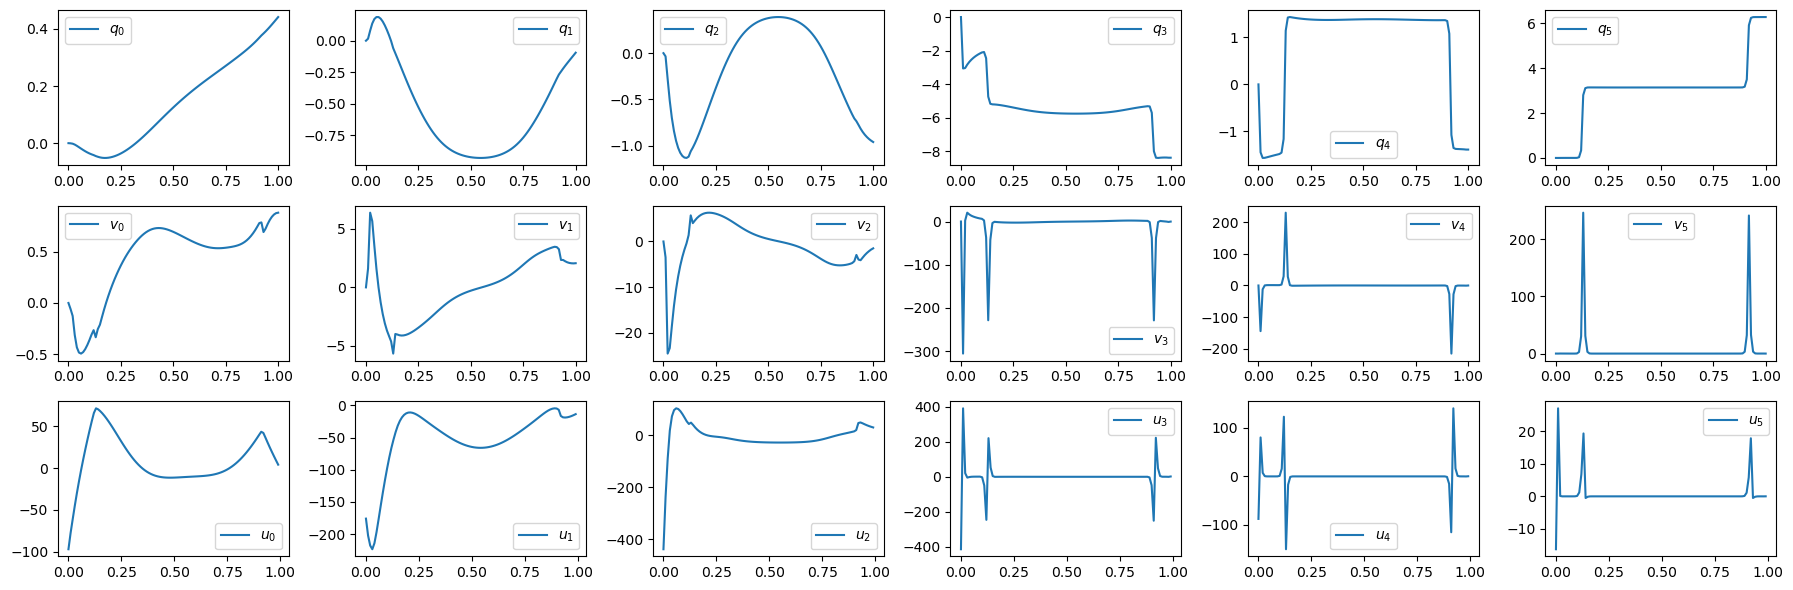

In [223]:
show_results(log)
plot_results(log)